# Feminist Art History NLP Project Experiment
This notebook implements an exploratory NLP pipeline on a small corpus of feminist art history texts, following the methods introduced in the course.

## I. Introduction & I. Corpus Preparation

## Setup & imports

### Dependencies

This notebook requires a small set of external Python libraries.
If any of them are not installed in the current environment,
please run the following cell once.

This project uses standard Python libraries for NLP and data analysis, including:
- numpy
- pandas
- scikit-learn
- matplotlib
- gensim (used for training word embeddings).

In [ ]:
# Install required libraries (run once if needed)
!pip install pymupdf sentence-transformers scikit-learn pandas numpy matplotlib


In [1]:
# Basic utilities
import os
from pathlib import Path

# Data handling
import pandas as pd
import numpy as np

# Text processing
import re

# PDF processing
import fitz  # PyMuPDF

# Vectorization
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# Topic modeling
from sklearn.decomposition import LatentDirichletAllocation

# Similarity & clustering
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import KMeans

# Embeddings
from sentence_transformers import SentenceTransformer

# Visualization
import matplotlib.pyplot as plt

### Project Paths

This section defines the project root and the input/output folders used in the pipeline.
Paths are built using `pathlib` to ensure cross-platform compatibility (Windows/macOS/Linux).


In [2]:
# Define project root directory
# This assumes the notebook is located inside the 'code/' folder
PROJECT_ROOT = Path.cwd().parents[0]

print("Project root:", PROJECT_ROOT)


Project root: C:\Users\ismin\Desktop\nlp-course\feminist_art_history_nlp


In [4]:
# Notebook is located in: feminist_art_history_nlp/data/code
# Go two levels up to reach the project root: feminist_art_history_nlp/
PROJECT_ROOT = Path.cwd().parents[0]

PDF_DIR = PROJECT_ROOT / "data" / "pdfs"
TEXT_DIR = PROJECT_ROOT / "data" / "texts"
OUTPUT_DIR = PROJECT_ROOT / "report" / "outputs"

# Create output folders if they don't exist
TEXT_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


print("PROJECT_ROOT:", PROJECT_ROOT)
print("PDF_DIR:", PDF_DIR)
print("TEXT_DIR:", TEXT_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR)
print("PDF count:", len(list(PDF_DIR.glob("*.pdf"))))


PROJECT_ROOT: C:\Users\ismin\Desktop\nlp-course\feminist_art_history_nlp
PDF_DIR: C:\Users\ismin\Desktop\nlp-course\feminist_art_history_nlp\data\pdfs
TEXT_DIR: C:\Users\ismin\Desktop\nlp-course\feminist_art_history_nlp\data\texts
OUTPUT_DIR: C:\Users\ismin\Desktop\nlp-course\feminist_art_history_nlp\report\outputs
PDF count: 9



## PDF to Text Conversion

The dataset consists of PDF files. Since NLP methods operate on plain text,
the PDFs are converted into UTF-8 `.txt` files prior to analysis.

Conversion is performed using PyMuPDF by extracting text page by page.
This step is executed once, and the resulting `.txt` files are stored in `data/texts/`.



In [5]:
def extract_text_from_pdf(pdf_path: Path) -> str:
    """
    Extract text from a PDF file using PyMuPDF.

    Parameters:
        pdf_path (Path): Path to a PDF file.

    Returns:
        str: Extracted text content from all pages.
    """
    doc = fitz.open(pdf_path)
    pages = []
    for page in doc:
        pages.append(page.get_text("text"))
    doc.close()
    return "\n".join(pages)


pdf_files = sorted(PDF_DIR.glob("*.pdf"))
print(f"Found {len(pdf_files)} PDF files for conversion.")

for pdf_file in pdf_files:
    text_content = extract_text_from_pdf(pdf_file)
    out_path = TEXT_DIR / f"{pdf_file.stem}.txt"
    out_path.write_text(text_content, encoding="utf-8")
    print(f"Saved: {out_path.name}")

print("PDF to text conversion completed.")


Found 9 PDF files for conversion.
Saved: _Post modernism and Feminist Art History The Reception of the Male Nude in 20th Greek Painting.txt
Saved: An unfinished revolution in art historiography or how to write a feminist art history.txt
Saved: Art History’s Feminist Emergencies.txt
Saved: Black Gold A Black Feminist .txt
Saved: FEMINISM IN THE TIME OF TRANSFORMATION.txt
Saved: Making black feminist american art histories.txt
Saved: Rape of the Earth. Ana Mendieta’s Defense of a Metaphor.txt
Saved: THE FIRST BIOGRAPHY OF ARTEMISIA GENTILESCHI.txt
Saved: The Writerly and the Dialogical Imagination of Feminist Art History.txt
PDF to text conversion completed.


## Load Corpus

This section loads the converted `.txt` files into memory. Each file corresponds
to one document in the corpus. The resulting list of documents will be used
for preprocessing and downstream NLP analysis.


In [6]:
documents = []
doc_names = []

txt_files = sorted(TEXT_DIR.glob("*.txt"))
print(f"Found {len(txt_files)} TXT files.")

for file in txt_files:
    doc_names.append(file.stem)
    text = file.read_text(encoding="utf-8", errors="ignore")
    documents.append(text)

print(f"Loaded {len(documents)} documents.")
print("Document names:", doc_names)



Found 9 TXT files.
Loaded 9 documents.
Document names: ['_Post modernism and Feminist Art History The Reception of the Male Nude in 20th Greek Painting', 'An unfinished revolution in art historiography or how to write a feminist art history', 'Art History’s Feminist Emergencies', 'Black Gold A Black Feminist ', 'FEMINISM IN THE TIME OF TRANSFORMATION', 'Making black feminist american art histories', 'Rape of the Earth. Ana Mendieta’s Defense of a Metaphor', 'THE FIRST BIOGRAPHY OF ARTEMISIA GENTILESCHI', 'The Writerly and the Dialogical Imagination of Feminist Art History']


## Text Preprocessing

Before applying vectorization and modeling techniques, the text data undergoes
a light preprocessing step. The goal is not to normalize the texts aggressively,
but to ensure basic consistency while preserving the interpretive and theoretical
language of the documents.

The preprocessing includes:
- lowercasing all text
- removal of numerical characters
- remove common bibliographic / editorial noise
- remove URLs and web-related residue
- normalization of whitespace


In [7]:
import re

def preprocess_text(text: str) -> str:
    """
    Apply minimal, targeted preprocessing to a text document.

    Steps:
    - convert to lowercase
    - remove digits
    - remove URLs and web-related residue
    - remove common bibliographic / editorial noise
    - normalize whitespace

    This function intentionally avoids aggressive linguistic normalization
    (e.g., lemmatization) to preserve art-historical vocabulary.
    """

    # Convert to lowercase
    text = text.lower()

    # Remove URLs (http, https, www, full links)
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)

    # Remove common web / domain tokens
    text = re.sub(
        r"\b(http|https|www|org|com|edu|net)\b",
        " ",
        text
    )

    # Remove digits (years, page numbers, etc.)
    text = re.sub(r"\d+", "", text)

    # Remove common bibliographic and editorial residue
    text = re.sub(
        r"\b(pp|p|vol|no|fig|folio|fol|appendix|downloaded|content|biography)\b",
        " ",
        text
    )

    # Remove frequent multilingual function words observed as TF-IDF noise
    text = re.sub(
        r"\b(et|la|le|si|ma|ne|non|al|ed|come)\b",
        " ",
        text
    )

    # Normalize whitespace
    text = re.sub(r"\s+", " ", text)

    return text.strip()


# Apply preprocessing to all documents
processed_documents = [preprocess_text(doc) for doc in documents]


# Random sanity-check snippet
import random
idx = random.randrange(len(processed_documents))

print("Text preprocessing completed.")
print(f"Number of processed documents: {len(processed_documents)}")
print(f"Example snippet from: {doc_names[idx]}\n")
print(processed_documents[idx][:400])


Text preprocessing completed.
Number of processed documents: 9
Example snippet from: An unfinished revolution in art historiography or how to write a feminist art history

open space an unfinished revolution in art historiography, or how to write a feminist art history  victoria horne and amy tobin the question implied in our title is more a clarion call, an open-ended research enquiry that we have begun thinking about through a series of informal research events. the first workshop, organised by victoria horne at the university of edinburgh, brought togethe


## II.  TF-IDF

## TF-IDF Vectorization

TF-IDF converts each document into a numerical feature representation. Terms are
weighted by their importance in a document relative to the whole corpus. This is
a standard representation for downstream NLP methods such as clustering or topic modeling.

TfidfVectorizer assigns a weight to each term based on:
- how often it appears in a document (TF)
- how rare it is across the corpus (IDF)


In [8]:
# Initialize the TF-IDF vectorizer
# - stop_words: remove common English function words
# - max_df: ignore terms that appear in more than 90% of documents
# - min_df: keep terms that appear in at least 2 documents
# - ngram_range: include unigrams and bigrams to capture multi-word expressions (e.g.feminist art, black women)
tfidf_vectorizer = TfidfVectorizer(
    stop_words="english",
    max_df=0.9,
    min_df=2,
    ngram_range=(1, 2)
)

# Fit the vectorizer to the preprocessed documents
# and transform them into a TF-IDF matrix
X_tfidf = tfidf_vectorizer.fit_transform(processed_documents)

# Retrieve the feature (term) names
feature_names = tfidf_vectorizer.get_feature_names_out()

# Print basic information about the TF-IDF representation
print("TF-IDF matrix shape:", X_tfidf.shape)
print("Number of features:", len(feature_names))

# Save a short summary of the TF-IDF representation for reporting purposes
with open(OUTPUT_DIR / "tfidf_summary.txt", "w", encoding="utf-8") as f:
    f.write(f"Documents: {len(doc_names)}\n")
    f.write(f"TF-IDF shape: {X_tfidf.shape}\n")
    f.write(f"Features: {len(feature_names)}\n")

print("TF-IDF summary saved to:", OUTPUT_DIR / "tfidf_summary.txt")

#Result: a document × term matrix
#each row = one document
#each column = one term
#each cell = importance of that term in that document

TF-IDF matrix shape: (9, 3404)
Number of features: 3404
TF-IDF summary saved to: C:\Users\ismin\Desktop\nlp-course\feminist_art_history_nlp\report\outputs\tfidf_summary.txt


## Top TF-IDF Terms per Document

This step extracts the highest-weighted TF-IDF terms for each document individually.
It supports qualitative inspection of dominant vocabulary and helps identify thematic
focus and residual noise in the corpus.


In [9]:
import numpy as np
import pandas as pd

# Use the TF-IDF matrix created in the previous step
feature_names = tfidf_vectorizer.get_feature_names_out()

#For each document, its top 15 TF-IDF terms are extracted
top_n = 15    #9 documents × 15 terms = 135 rows
rows = []

# Extract top TF-IDF terms for each document separately
for i, doc_name in enumerate(doc_names):
    row = X_tfidf[i].toarray().ravel()      # use X_tfidf (correct variable)
    top_idx = row.argsort()[::-1][:top_n]

    for rank, j in enumerate(top_idx, start=1):
        if row[j] > 0:
            rows.append({
                "document": doc_name,   # source document
                "rank": rank,           # importance rank within document
                "term": feature_names[j],
                "tfidf": row[j]
            })

# Create inspection-friendly DataFrame
df_top_per_doc = pd.DataFrame(rows)

df_top_per_doc



,document,rank,term,tfidf
0,_Post modernism and Feminist Art History The R...,1,greece,0.429425
1,_Post modernism and Feminist Art History The R...,2,male,0.279566
2,_Post modernism and Feminist Art History The R...,3,painting,0.215117
3,_Post modernism and Feminist Art History The R...,4,modernism,0.190324
4,_Post modernism and Feminist Art History The R...,5,postmodern,0.189938
...,...,...,...,...
130,The Writerly and the Dialogical Imagination of...,11,public,0.097729
131,The Writerly and the Dialogical Imagination of...,12,black,0.087962
132,The Writerly and the Dialogical Imagination of...,13,books,0.086514
133,The Writerly and the Dialogical Imagination of...,14,movement,0.086514


### Reading the output
In the document titled:Postmodernism and Feminist Art History: The Reception of the Male Nude in Twentieth-Century Greek Painting, the dominant TF-IDF terms highlight a national and historical focus (“Greece”), a sustained engagement with gendered representation (“male,” “nude,” “body”), and a strong theoretical framing (“modernism,” “postmodernism,” “discourse”). Together, these terms reflect the text’s analysis of how feminist art-historical interpretation negotiates national context and shifting theoretical paradigms.

## Compact Overview of Top TF-IDF Terms per Document

Instead of having many rows per document (one row per term), it:
- groups all TF-IDF terms by document
- collects each document’s top-ranked terms into a single list
- produces one compact row per document, which is easier to read and compare


In [10]:
# Group TF-IDF inspection results by document
# and collect top-ranked terms into a list per document
# This produces one row per document (compact overview)

df_compact = (
    df_top_per_doc
    .groupby("document")["term"]   # group rows by document and select term column
    .apply(list)                   # aggregate terms into a list
    .reset_index()                 # restore document as a column
)

# Display compact per-document term overview
df_compact


,document,term
0,An unfinished revolution in art historiography...,"[feminist art, knowledge, collective, feminism..."
1,Art History’s Feminist Emergencies,"[feminism, horne, conference, museum, exhibiti..."
2,Black Gold A Black Feminist,"[black, black women, black feminist, race, com..."
3,FEMINISM IN THE TIME OF TRANSFORMATION,"[communist, cat, exhibition, feminism, text, e..."
4,Making black feminist american art histories,"[fuller, black, american, american art, sculpt..."
5,Rape of the Earth. Ana Mendieta’s Defense of a...,"[rape, violence, index, nature, camera, object..."
6,THE FIRST BIOGRAPHY OF ARTEMISIA GENTILESCHI,"[note, maria, use, se, women artists, subject,..."
7,The Writerly and the Dialogical Imagination of...,"[lozano, applin, writing, piper, spero, piece,..."
8,_Post modernism and Feminist Art History The R...,"[greece, male, painting, modernism, postmodern..."


##  TF-IDF Heatmap (Documents × Top Terms)

This visualization displays TF-IDF weights for a small set of globally salient terms
across all documents. It supports qualitative comparison by showing which terms
concentrate in which texts (discursive differentiation within a homogeneous corpus).


C:\Users\ismin\AppData\Local\Temp\ipykernel_6172\4002969810.py:29: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


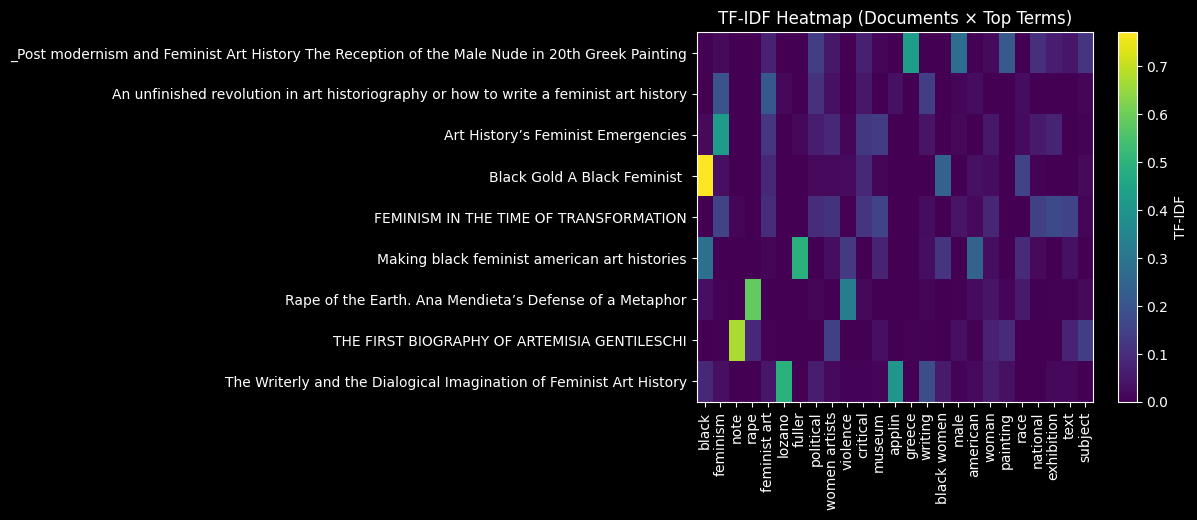

,black,feminism,note,rape,feminist art,lozano,fuller,political,women artists,violence,...,black women,male,american,woman,painting,race,national,exhibition,text,subject
_Post modernism and Feminist Art History The Reception of the Male Nude in 20th Greek Painting,0.005083,0.020709,0.000000,0.000000,0.070409,0.000000,0.000000,0.142075,0.049701,0.000000,...,0.000000,0.279566,0.004142,0.020709,0.215117,0.000000,0.107559,0.062271,0.045751,0.114576
An unfinished revolution in art historiography or how to write a feminist art history,0.000000,0.196092,0.000000,0.000000,0.213918,0.017772,0.000000,0.108493,0.035653,0.000000,...,0.000000,0.009863,0.026740,0.000000,0.000000,0.024366,0.000000,0.000000,0.000000,0.009863
Art History’s Feminist Emergencies,0.020008,0.423853,0.000000,0.000000,0.122265,0.000000,0.016252,0.063137,0.089661,0.011141,...,0.000000,0.018039,0.000000,0.048906,0.000000,0.022282,0.055705,0.077987,0.000000,0.009020
Black Gold A Black Feminist,0.771467,0.031428,0.000000,0.000000,0.090093,0.000000,0.000000,0.020866,0.018857,0.022910,...,0.243364,0.000000,0.035618,0.025142,0.002864,0.154642,0.008591,0.000000,0.000000,0.018548
FEMINISM IN THE TIME OF TRANSFORMATION,0.000000,0.158112,0.012610,0.000000,0.101192,0.000000,0.000000,0.097978,0.113841,0.000000,...,0.000000,0.041990,0.018973,0.082218,0.000000,0.000000,0.146955,0.172889,0.155249,0.013997
Making black feminist american art histories,0.285496,0.000000,0.000000,0.000000,0.013683,0.000000,0.491082,0.000000,0.027366,0.130914,...,0.118606,0.000000,0.246293,0.027366,0.000000,0.093510,0.018702,0.000000,0.033588,0.000000
Rape of the Earth. Ana Mendieta’s Defense of a Metaphor,0.031928,0.007432,0.000000,0.585370,0.000000,0.000000,0.000000,0.012337,0.000000,0.325081,...,0.000000,0.004112,0.022297,0.040878,0.010159,0.055873,0.000000,0.005079,0.004561,0.020561
THE FIRST BIOGRAPHY OF ARTEMISIA GENTILESCHI,0.000000,0.003158,0.673728,0.088151,0.006316,0.000000,0.000000,0.000000,0.145264,0.000000,...,0.000000,0.031450,0.003158,0.069474,0.090642,0.000000,0.000000,0.000000,0.073642,0.139776
The Writerly and the Dialogical Imagination of Feminist Art History,0.087962,0.032576,0.000000,0.000000,0.045607,0.493649,0.000000,0.057676,0.019546,0.008905,...,0.056475,0.007210,0.019546,0.058637,0.035621,0.000000,0.000000,0.017810,0.015993,0.000000


In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ----------------------------
# Select top terms globally (by average TF-IDF)
# ----------------------------
feature_names = tfidf_vectorizer.get_feature_names_out()

avg_tfidf = np.asarray(X_tfidf.mean(axis=0)).ravel()
top_n_terms = 25  # keep small for readability

top_idx = avg_tfidf.argsort()[::-1][:top_n_terms]
top_terms = feature_names[top_idx]

# Build a small (docs × top terms) matrix
X_small = X_tfidf[:, top_idx].toarray()
df_tfidf_heatmap = pd.DataFrame(X_small, index=doc_names, columns=top_terms)

# ----------------------------
# Plot heatmap (matplotlib only)
# ----------------------------
plt.figure()
plt.imshow(df_tfidf_heatmap.values, aspect="auto")
plt.xticks(range(len(top_terms)), top_terms, rotation=90)
plt.yticks(range(len(doc_names)), doc_names)
plt.colorbar(label="TF-IDF")
plt.title("TF-IDF Heatmap (Documents × Top Terms)")
plt.tight_layout()
plt.show()

df_tfidf_heatmap


## Interpretation of TF-IDF Inspection

- The corpus separates into clear thematic clusters, including Black feminist art history (race, Harlem Renaissance, community), feminist historiography and theory (writing, collectives, historiography, Pollock), and case studies centered on gendered violence and the body.
- Texts on Black feminist art history foreground race, community, and historical recovery, reflecting a strong intersectional perspective distinct from Eurocentric feminist narratives.
- Case studies (e.g. Ana Mendieta; the male nude in Greek painting) are characterized by embodied and political vocabulary related to violence, sexuality, nationalism, and discourse.
- Meta-historiographic texts emphasize writing, knowledge production, and collective practice, framing feminist art history as an ongoing methodological and epistemological project rather than a fixed canon.


## III. LDA Topic Modeling

Latent Dirichlet Allocation (LDA) is used here as an exploratory method to identify
recurring thematic structures within a small, curated corpus of feminist art-historical
texts. Rather than producing definitive topic labels, LDA supports qualitative analysis
by revealing how discourses around feminism, race, violence, historiography, and
artistic practice co-occur across documents.

In its standard formulation, LDA operates on document–term matrices, such as Bag-of-Words
(count) or term-frequency representations. In this project, a Bag-of-Words matrix is used,
as raw term counts align more closely with the generative assumptions of LDA and are
commonly employed in practical implementations. The same conservative filtering strategy
applied in earlier steps is retained to maintain interpretability within a small corpus.


### 1) Bag-of-Words Representation for Topic Modeling

LDA topic modeling is performed on a Bag-of-Words (count-based) representation of the
preprocessed feminist art-historical corpus. Raw term counts are used to align with
the generative assumptions of LDA and to support interpretable topic-word distributions
in a small, curated corpus.


In [12]:
from sklearn.feature_extraction.text import CountVectorizer

# Build Bag-of-Words (count) matrix for LDA
count_vectorizer = CountVectorizer(
    stop_words="english",
    max_df=0.9,             # remove corpus-wide boilerplate
    min_df=2,               # keep terms shared by at least two documents
    ngram_range=(1, 2)      # capture relevant multi-word expressions
)

X_counts = count_vectorizer.fit_transform(processed_documents)
count_feature_names = count_vectorizer.get_feature_names_out()

print("Count matrix shape:", X_counts.shape)
print("Number of count features:", len(count_feature_names))


Count matrix shape: (9, 3404)
Number of count features: 3404


### Understanding the Shape of the Count Matrix

The resulting count matrix has a shape of (9, 3404),indicating that the corpus
contains nine documents represented across 3,404 unique word and bigram features.
So each document is represented as a 3,404-dimensional vector of word counts.

This relatively large vocabulary reflects the lexical richness of full-length
academic texts and the inclusion of multi-word expressions. Given the small number
of documents, topic modeling results should be interpreted heuristically, as
exploratory indicators of dominant discursive patterns rather than statistically
stable topics.


### 2) Fitting the LDA Topic Model

The LDA model is fitted to the count-based document–term matrix. Given the small size
of the corpus, the number of topics is intentionally kept low to avoid unstable or
over-fragmented topic structures. The resulting model provides topic–word distributions
and document–topic mixtures for qualitative interpretation.


In [13]:
from sklearn.decomposition import LatentDirichletAllocation

# Fit LDA model (small corpus -> low number of topics)
n_topics = 4

lda_model = LatentDirichletAllocation(
    n_components=n_topics,
    random_state=42,
    learning_method="batch"
)

doc_topic = lda_model.fit_transform(X_counts)

print("Doc-topic matrix shape:", doc_topic.shape)


Doc-topic matrix shape: (9, 4)


### 3) Topic–Word Distributions

This step inspects the internal structure of the fitted LDA model by examining the
most highly weighted terms for each topic. Topic–word distributions are interpreted
qualitatively and treated as heuristic indicators of recurring discursive patterns,
not as fixed or exhaustive thematic labels.


In [14]:
import pandas as pd
import numpy as np

# Number of top terms to display per topic
top_n_terms = 12

topics = []

# Extract top terms for each topic
for topic_idx, topic_weights in enumerate(lda_model.components_):
    top_idx = topic_weights.argsort()[::-1][:top_n_terms]
    top_terms = [count_feature_names[i] for i in top_idx]

    topics.append({
        "topic": f"Topic {topic_idx}",
        "top_terms": top_terms
    })

# Create inspection-friendly DataFrame
df_topics = pd.DataFrame(topics)

df_topics


,topic,top_terms
0,Topic 0,"[meta, remaking, seminar, fuller, mass, female..."
1,Topic 1,"[feminism, feminist art, rape, political, male..."
2,Topic 2,"[black, note, black women, race, women artists..."
3,Topic 3,"[meta, remaking, seminar, fuller, mass, female..."


### 4) Document–Topic Mixture Weights

Each document is represented as a probability mixture over the learned topics.
These mixture weights indicate the relative prominence of each topic within a given
text and support comparative, document-level interpretation across the corpus.


In [15]:
# Create document–topic weight table
df_doc_topics = pd.DataFrame(
    doc_topic,
    columns=[f"Topic {i}" for i in range(n_topics)]
)

# Add document identifiers
df_doc_topics.insert(0, "document", doc_names)

df_doc_topics


,document,Topic 0,Topic 1,Topic 2,Topic 3
0,_Post modernism and Feminist Art History The R...,0.000069,0.999788,0.000073,0.000069
1,An unfinished revolution in art historiography...,0.000149,0.999542,0.000159,0.000149
2,Art History’s Feminist Emergencies,0.000133,0.999593,0.000142,0.000133
3,Black Gold A Black Feminist,0.000053,0.000056,0.999838,0.000053
4,FEMINISM IN THE TIME OF TRANSFORMATION,0.000107,0.999671,0.000115,0.000107
5,Making black feminist american art histories,0.000381,0.459644,0.539594,0.000381
6,Rape of the Earth. Ana Mendieta’s Defense of a...,0.000078,0.999760,0.000084,0.000078
7,THE FIRST BIOGRAPHY OF ARTEMISIA GENTILESCHI,0.000071,0.000075,0.999782,0.000071
8,The Writerly and the Dialogical Imagination of...,0.000134,0.980426,0.019306,0.000134


### 5) Saving LDA Outputs

For transparency and reporting purposes, both the topic–word distributions and the
document–topic mixture weights are saved to disk.


In [16]:
# Save topic–word distributions
with open(OUTPUT_DIR / "lda_topics.txt", "w", encoding="utf-8") as f:
    f.write(f"Documents: {len(doc_names)}\n")
    f.write(f"Topics: {n_topics}\n\n")
    for row in topics:
        f.write(f"{row['topic']}: {', '.join(row['top_terms'])}\n")

# Save document–topic mixtures
df_doc_topics.to_csv(OUTPUT_DIR / "lda_doc_topic_weights.csv", index=False)

print("Saved:", OUTPUT_DIR / "lda_topics.txt")
print("Saved:", OUTPUT_DIR / "lda_doc_topic_weights.csv")


Saved: C:\Users\ismin\Desktop\nlp-course\feminist_art_history_nlp\report\outputs\lda_topics.txt
Saved: C:\Users\ismin\Desktop\nlp-course\feminist_art_history_nlp\report\outputs\lda_doc_topic_weights.csv


### 6) LDA Topic–Term Bar Plots

This visualization shows the highest-weighted terms for each LDA topic. Bar plots are
preferred over word clouds because they preserve rank and magnitude, supporting
transparent qualitative interpretation of topic structure.


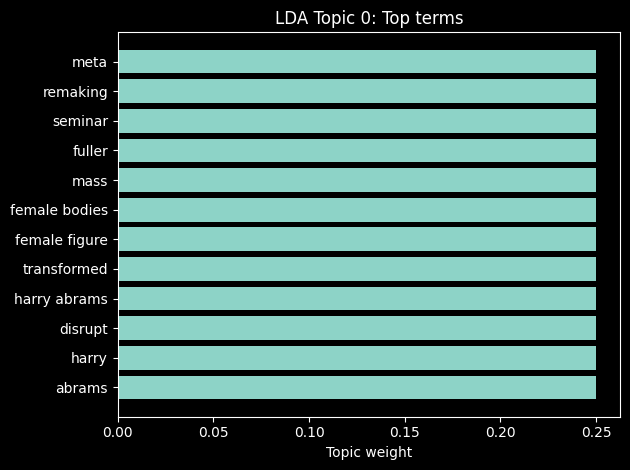

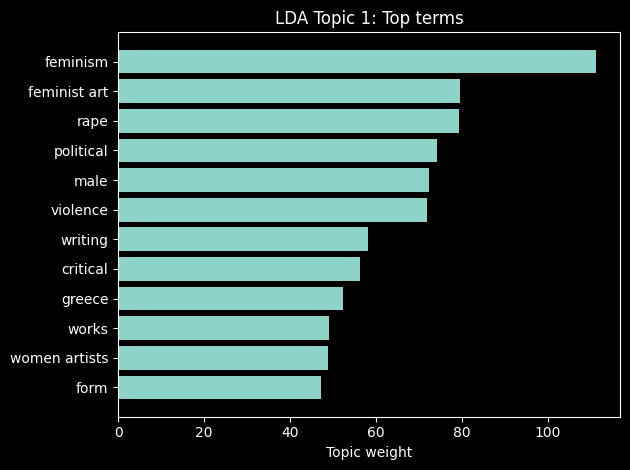

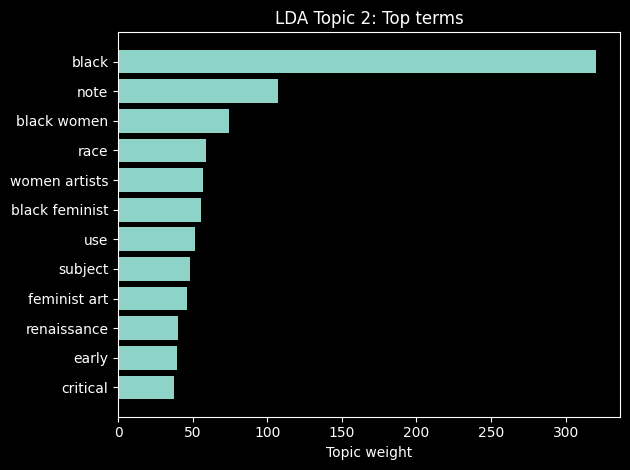

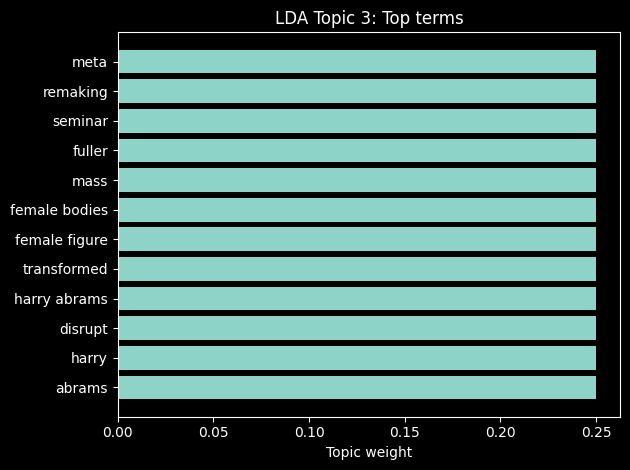

In [17]:
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# Plot top terms per topic
# ----------------------------
top_n_terms = 12

for topic_idx, topic_weights in enumerate(lda_model.components_):
    # Select top terms for this topic
    top_idx = topic_weights.argsort()[::-1][:top_n_terms]
    terms = [count_feature_names[i] for i in top_idx]
    weights = topic_weights[top_idx]

    # Bar plot (one plot per topic; no seaborn; no custom colors)
    plt.figure()
    plt.barh(terms[::-1], weights[::-1])
    plt.xlabel("Topic weight")
    plt.title(f"LDA Topic {topic_idx}: Top terms")
    plt.tight_layout()
    plt.show()


## Evaluation of LDA Topic Modeling

The LDA topic modeling results show that, even within a relatively homogeneous corpus
focused on feminist art history, probabilistic topic models can identify distinct
thematic patterns and scholarly orientations. The learned topics differentiate between
texts centered on Black feminist historiography, case studies addressing violence and
embodiment, and meta-historiographic or theoretical reflections on feminist art history
as a discipline.

Beyond document-level exploration, this form of thematic mapping is particularly relevant
for future multimodal analysis. By modeling shared thematic structures across texts, LDA
can support the alignment of art-historical literature with visual materials that engage
similar concerns, enabling a parallel study of artworks and their associated scholarship.
In this sense, topic modeling functions less as an interpretive endpoint than as an
organizational layer that facilitates comparative analysis across textual and visual
domains.


## IV. Semantic Representation: Word Embeddings

Word embedding–based similarity constitutes the third NLP technology used in this
experiment. Unlike TF-IDF and LDA, which emphasize term salience and thematic structure,
word embeddings model semantic proximity beyond exact lexical overlap.

In this project, embedding-based similarity is used exploratorily to compare feminist
art-historical texts at a conceptual level and to complement earlier representations
rather than replace them.


In [18]:
from gensim.models import Word2Vec

# Tokenize documents (simple whitespace tokenization after preprocessing)
tokenized_docs = [doc.split() for doc in processed_documents]

# Train Word2Vec model on the small corpus
# (parameters kept conservative due to corpus size)
w2v_model = Word2Vec(
    sentences=tokenized_docs,   # tokenized documents used to learn word contexts
    vector_size=100,            # dimensionality of word embeddings
    window=5,                   # context window size (words before/after target)
    min_count=2,                # ignore words that appear fewer than 2 times
    workers=2,                  # number of CPU threads used for training
    seed=42                     # fixed seed for reproducible results
)


print("Word2Vec vocabulary size:", len(w2v_model.wv))


Word2Vec vocabulary size: 6149


### Interpreting the Word2Vec Vocabulary Size
The Word2Vec model learned vector representations for 6,152 unique tokens.
These are:
- words that survived preprocessing
- that occur at least twice in the corpus (min_count=2)
- Each of these tokens now has a 100-dimensional semantic vector
So the embedding space contains 6,152 points (words).

### 2) Document Embeddings (Averaged Word Vectors)

Each document is represented by the average of its word embeddings. This produces a
dense vector representation per document, allowing comparison in semantic space.


In [19]:
import numpy as np
import pandas as pd

def document_embedding(tokens, model):
    """Compute average word embedding for a document."""
    # collect embeddings for words that exist in the model vocabulary
    vectors = [
        model.wv[word]
        for word in tokens
        if word in model.wv
    ]
    # return mean vector, or zero vector if no valid words are found
    return np.mean(vectors, axis=0) if vectors else np.zeros(model.vector_size)

# compute one embedding per document
doc_embeddings = np.vstack([
    document_embedding(tokens, w2v_model)
    for tokens in tokenized_docs
])

# inspect document embedding matrix dimensions
print("Document embedding matrix shape:", doc_embeddings.shape)


Document embedding matrix shape: (9, 100)


### 3) Document Similarity in Embedding Space

Cosine similarity is used to measure semantic proximity between documents based on
their embedding representations.


In [20]:
from sklearn.metrics.pairwise import cosine_similarity

# compute pairwise cosine similarity between document embeddings
embedding_similarity = cosine_similarity(doc_embeddings)

# convert similarity matrix to labeled DataFrame for inspection
df_embedding_similarity = pd.DataFrame(
    embedding_similarity,
    index=doc_names,
    columns=doc_names
)

df_embedding_similarity


,_Post modernism and Feminist Art History The Reception of the Male Nude in 20th Greek Painting,An unfinished revolution in art historiography or how to write a feminist art history,Art History’s Feminist Emergencies,Black Gold A Black Feminist,FEMINISM IN THE TIME OF TRANSFORMATION,Making black feminist american art histories,Rape of the Earth. Ana Mendieta’s Defense of a Metaphor,THE FIRST BIOGRAPHY OF ARTEMISIA GENTILESCHI,The Writerly and the Dialogical Imagination of Feminist Art History
_Post modernism and Feminist Art History The Reception of the Male Nude in 20th Greek Painting,1.000000,0.999999,0.999994,0.999995,0.999981,0.999995,0.999999,0.999934,0.999999
An unfinished revolution in art historiography or how to write a feminist art history,0.999999,1.000000,0.999995,0.999996,0.999980,0.999995,0.999998,0.999935,0.999999
Art History’s Feminist Emergencies,0.999994,0.999995,1.000000,1.000000,0.999994,0.999999,0.999994,0.999963,0.999995
Black Gold A Black Feminist,0.999995,0.999996,1.000000,1.000000,0.999993,0.999999,0.999995,0.999962,0.999995
FEMINISM IN THE TIME OF TRANSFORMATION,0.999981,0.999980,0.999994,0.999993,1.000000,0.999994,0.999982,0.999985,0.999981
Making black feminist american art histories,0.999995,0.999995,0.999999,0.999999,0.999994,1.000000,0.999996,0.999963,0.999996
Rape of the Earth. Ana Mendieta’s Defense of a Metaphor,0.999999,0.999998,0.999994,0.999995,0.999982,0.999996,1.000000,0.999938,1.000000
THE FIRST BIOGRAPHY OF ARTEMISIA GENTILESCHI,0.999934,0.999935,0.999963,0.999962,0.999985,0.999963,0.999938,1.000000,0.999938
The Writerly and the Dialogical Imagination of Feminist Art History,0.999999,0.999999,0.999995,0.999995,0.999981,0.999996,1.000000,0.999938,1.000000


### 4) Visualization of Embedding-Based Similarity


C:\Users\ismin\AppData\Local\Temp\ipykernel_6172\3949460865.py:9: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


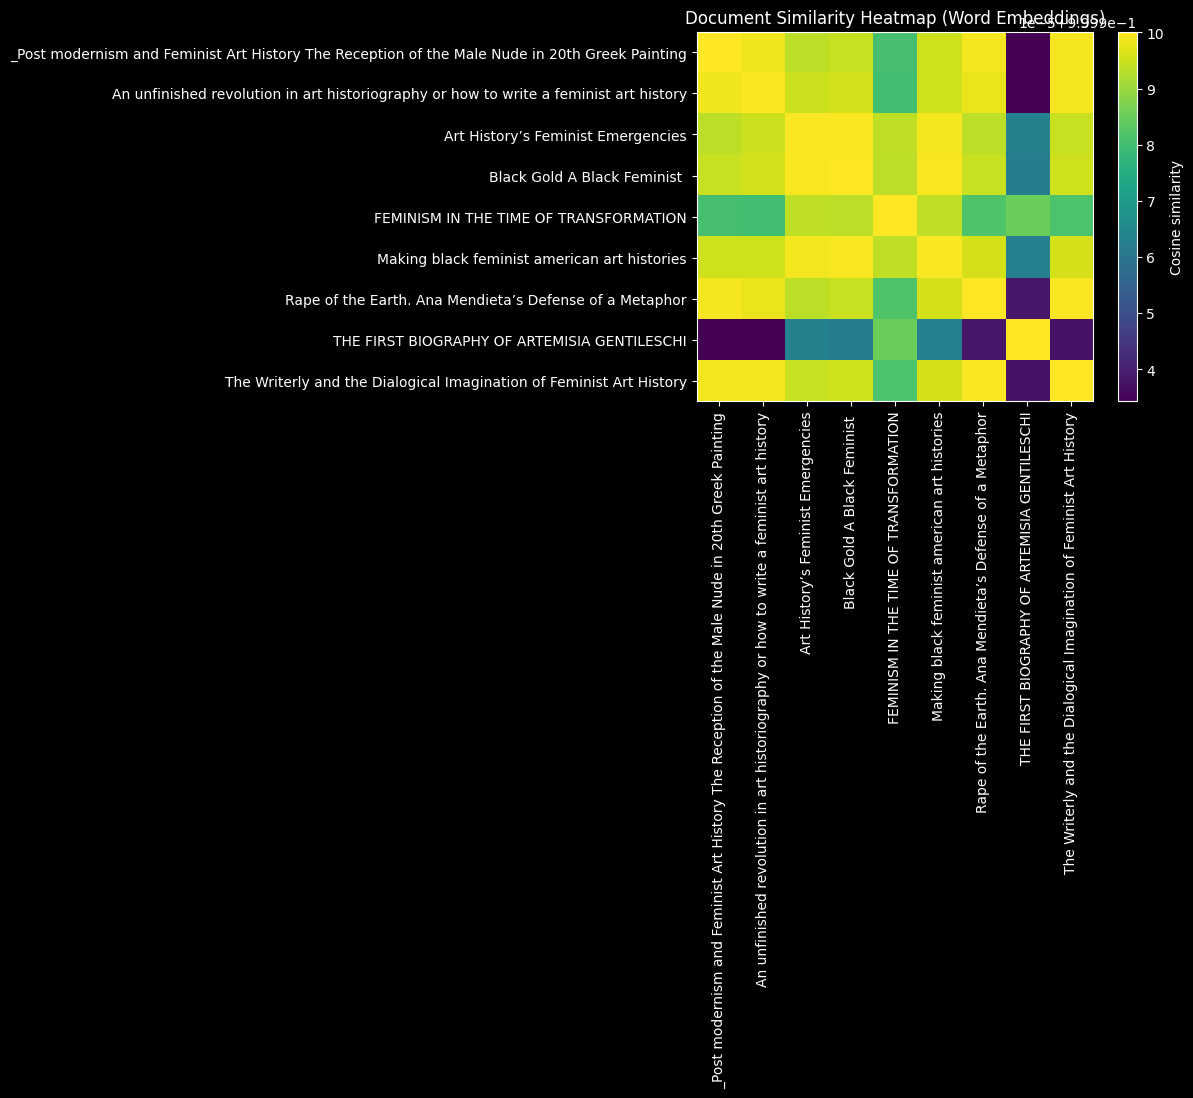

In [21]:
import matplotlib.pyplot as plt

plt.figure()
plt.imshow(df_embedding_similarity.values, aspect="auto")
plt.xticks(range(len(doc_names)), doc_names, rotation=90)
plt.yticks(range(len(doc_names)), doc_names)
plt.colorbar(label="Cosine similarity")
plt.title("Document Similarity Heatmap (Word Embeddings)")
plt.tight_layout()
plt.show()


## Evaluation of Word Embedding–Based Similarity

Embedding-based similarity provides a complementary perspective on document relationships
by emphasizing semantic proximity rather than shared terminology. Given the focused and
thematically coherent nature of the corpus, overall similarity scores are relatively high.
Nevertheless, the embedding-based analysis is able to differentiate between distinct
scholarly orientations within feminist art-historical writing, revealing nuanced patterns
of conceptual proximity and distance between texts.

Used alongside TF-IDF similarity and LDA topic modeling, word embeddings contribute to a
multi-perspectival analysis of textual relationships. Rather than replacing earlier
representations, they extend the analytical framework by foregrounding semantic affinities
that cut across lexical variation, supporting the project’s broader goal of comparing
interpretive orientations within feminist art-historical scholarship.
